## 05.2 Spatiotemporal Data 2: Multifile Datasets

### 1. Introduction

Often times, it's the case that our spatiotemporal datasets are comprised not of 1 file, but of many. Specific examples where this is true include:

1. Time series of remote sensing data, where the data is released on the same geospatial footprint at specified intervals (e.g., Landsat row and path footprints),
2. Weather forecasting data where each file may be a forecast for a set lead time into the future from a particular initial starting point, 
3. Climate projection data where each file may contain a year or even a decade of climate information under some given scenario,
4. Output of some kind of geophysical model like an ice sheet transport, hydrologic, or snow accumulation and melt model. 

We also previously saw that the NetCDF file format conveys a lot of advantages because we can store many different variables in the same file, as long as the variables can be described using one or more of the dimensions and coordinate axes describing the file. A double-edged sword of this flexibility, however, lies in the fact that our files can grow very large, very quickly. As I mentioned in class, __one day (24 hours)__ of raw simulated WRF output for our southern Idaho domain produces a single NetCDF file that is 15 GB in size – or about 5.5 TB for a full year of simulation. This predicament leads us to the following sets of questions:

- How can we analyze a dataset that is comprised of multiple files, as if it were a single dataset?
- Is there a way to analyze multifile datasets, when the sum total of all of the files in the dataet exceed our RAM for our individual machine?

Thankfully, `xArray` provides us an answer to both of the above questions. First some background on the data we'll be using today, and the event we'll be investigating. 

By late May 2010, the water year in the Boise and Payette River basins was shaping up to be great in terms of water resources. Reservoirs were almost full and there was still significant snow at the higher elevations of many water supply basins. However, in early June, a late atmospheric river (AR) would dump significant rain over southwest Idaho, melting a lot of snow in the upper basins and causing rivers to flood. Check out the summary of this event, on the Boise NWS website: [https://www.weather.gov/safety/flood-states-id](https://www.weather.gov/safety/flood-states-id). 

Many historical weather and climate datasets are not sufficiently fine in spatial or temporal resolutions to be able to analyze the hour-to-hour evolution of this event. As such, we have trouble asking and answering questions like "how did the rain-snow transition evolve over the course of this storm?" or "how did peak-hourly precipitation during the storm vary in space?" Today, you will be an early adopter of NASA's North American Land Data Assimilation, version 3 (NLDAS-3) data, a new dataset that provides estimates of hydrometeorological variables at 1 km, 1 hr spatiotemporal resolution over all of North America by combining physics based models with available remote sensing data. Read more about NLDAS-3 data here: [https://ldas.gsfc.nasa.gov/nldas/v3](https://ldas.gsfc.nasa.gov/nldas/v3)

This notebook uses NLDAS-3 hydrometeorological forcing data to analyze climate conditions in May and June 2010 and assess what fraction of precipitation that fell during those months was associated with this lone AR event. 

### 2. Imports and Definitions

In [ ]:
import numpy as np # Needed for numerical operations
import matplotlib.pyplot as plt # Needed for plotting
import xarray as xr # Needed for handling NetCDF data
import cartopy.crs as ccrs # Needed for cartographic projections
import cartopy.feature as cfeature # Needed for cartographic features
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter # Needed for formatting tick labels
from metpy.plots import USCOUNTIES # Needed for US counties feature

# Output file parameters
nldas3_dir = '../data/ubrb_nldas3/' # Directory for NLDAS-3 data
nldas3_filebase = 'nldas3_UBRB_subset_' # Base name for NLDAS-3 files
nldas3_fileext = '.nc' # File extension for NLDAS-3 files

### 3. Load the Data

Amazingly, `xArray` can load a multiple-file dataset with a single line of code. We just need to make sure we tell `xArray` how the multiple files in our dataset should be combined. Let's examine what the "loaded" dataset looks like and talk about a few things that distinguish the dataset from the underlying files. Specifically, try to find something called "chunksize" and see if you can surmise what it might mean. 

In [2]:
nldas3_ubrb_ds = xr.open_mfdataset(nldas3_dir+nldas3_filebase+'*'+nldas3_fileext, combine='by_coords')
nldas3_ubrb_ds

<xarray.Dataset> Size: 610MB
Dimensions:      (time: 1464, lat: 88, lon: 148)
Coordinates:
  * lon          (lon) float32 592B -116.1 -116.1 -116.1 ... -114.6 -114.6
  * lat          (lat) float32 352B 43.22 43.24 43.24 43.26 ... 44.08 44.08 44.1
  * time         (time) datetime64[ns] 12kB 2010-05-01 ... 2010-06-30T23:00:00
Data variables:
    spatial_ref  (time) int64 12kB 0 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0 0
    Tair         (time, lat, lon) float32 76MB dask.array<chunksize=(24, 88, 148), meta=np.ndarray>
    Qair         (time, lat, lon) float32 76MB dask.array<chunksize=(24, 88, 148), meta=np.ndarray>
    PSurf        (time, lat, lon) float32 76MB dask.array<chunksize=(24, 88, 148), meta=np.ndarray>
    LWdown       (time, lat, lon) float32 76MB dask.array<chunksize=(24, 88, 148), meta=np.ndarray>
    SWdown       (time, lat, lon) float32 76MB dask.array<chunksize=(24, 88, 148), meta=np.ndarray>
    Wind_N       (time, lat, lon) float32 76MB dask.array<chunksize=(24, 88, 148), meta=np.ndarray>
    Wind_E       (time, lat, lon) float32 76MB dask.array<chunksize=(24, 88, 148), meta=np.ndarray>
    Rainf        (time, lat, lon) float32 76MB dask.array<chunksize=(24, 88, 148), meta=np.ndarray>
Attributes: (12/17)
    missing_value:          -9999.0
    time_definition:        hourly
    shortname:              NLDAS_FOR0010_H_3.0
    title:                  NLDAS Forcing Data L4 Hourly 0.01 x 0.01 degree V...
    version:                3.0 beta
    institution:            NASA GSFC
    ...                     ...
    websites:               https://ldas.gsfc.nasa.gov/nldas/v3/ ; https://li...
    MAP_PROJECTION:         EQUIDISTANT CYLINDRICAL
    SOUTH_WEST_CORNER_LAT:  7.005
    SOUTH_WEST_CORNER_LON:  -168.995
    DX:                     0.01
    DY:                     0.01

### 4. Plot the Total Precipitation

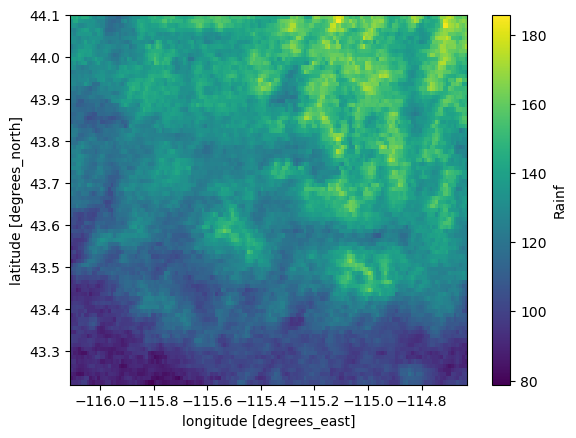

In [3]:
nldas3_ubrb_ds['Rainf'].sum(dim='time').plot()

### 5. Isolate AR and non-AR Periods for Analysis

In [4]:
ar_ds = nldas3_ubrb_ds.sel(time=slice('2010-06-02','2010-06-04'))
ar_ds

<xarray.Dataset> Size: 30MB
Dimensions:      (time: 72, lat: 88, lon: 148)
Coordinates:
  * lon          (lon) float32 592B -116.1 -116.1 -116.1 ... -114.6 -114.6
  * lat          (lat) float32 352B 43.22 43.24 43.24 43.26 ... 44.08 44.08 44.1
  * time         (time) datetime64[ns] 576B 2010-06-02 ... 2010-06-04T23:00:00
Data variables:
    spatial_ref  (time) int64 576B 0 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0 0
    Tair         (time, lat, lon) float32 4MB dask.array<chunksize=(24, 88, 148), meta=np.ndarray>
    Qair         (time, lat, lon) float32 4MB dask.array<chunksize=(24, 88, 148), meta=np.ndarray>
    PSurf        (time, lat, lon) float32 4MB dask.array<chunksize=(24, 88, 148), meta=np.ndarray>
    LWdown       (time, lat, lon) float32 4MB dask.array<chunksize=(24, 88, 148), meta=np.ndarray>
    SWdown       (time, lat, lon) float32 4MB dask.array<chunksize=(24, 88, 148), meta=np.ndarray>
    Wind_N       (time, lat, lon) float32 4MB dask.array<chunksize=(24, 88, 148), meta=np.ndarray>
    Wind_E       (time, lat, lon) float32 4MB dask.array<chunksize=(24, 88, 148), meta=np.ndarray>
    Rainf        (time, lat, lon) float32 4MB dask.array<chunksize=(24, 88, 148), meta=np.ndarray>
Attributes: (12/17)
    missing_value:          -9999.0
    time_definition:        hourly
    shortname:              NLDAS_FOR0010_H_3.0
    title:                  NLDAS Forcing Data L4 Hourly 0.01 x 0.01 degree V...
    version:                3.0 beta
    institution:            NASA GSFC
    ...                     ...
    websites:               https://ldas.gsfc.nasa.gov/nldas/v3/ ; https://li...
    MAP_PROJECTION:         EQUIDISTANT CYLINDRICAL
    SOUTH_WEST_CORNER_LAT:  7.005
    SOUTH_WEST_CORNER_LON:  -168.995
    DX:                     0.01
    DY:                     0.01

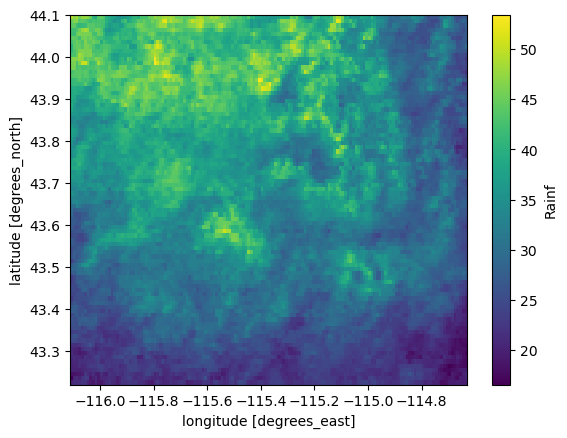

In [5]:
ar_ds['Rainf'].sum(dim='time').plot()

In [6]:
ar_before_ds = nldas3_ubrb_ds.sel(time=slice('2010-05-01','2010-06-01'))
ar_after_ds = nldas3_ubrb_ds.sel(time=slice('2010-06-05','2010-06-30'))

prcp_no_ar = ar_before_ds['Rainf'].sum(dim='time') + ar_after_ds['Rainf'].sum(dim='time')

In [7]:
type(prcp_no_ar)

xarray.core.dataarray.DataArray

In [8]:
prcp_ar = ar_ds['Rainf'].sum(dim='time')

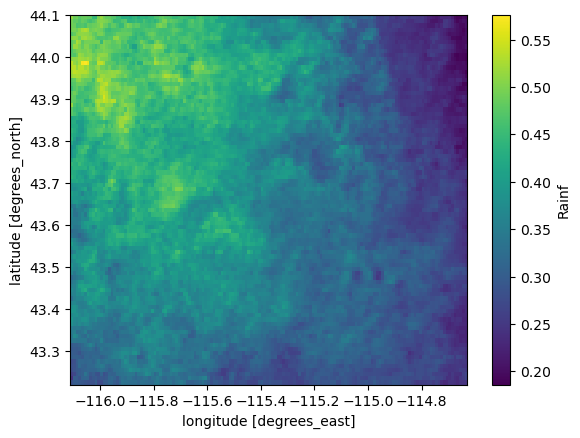

In [9]:
ar_frac = prcp_ar / prcp_no_ar

ar_frac.plot()

### 6. Create Maps with Spatial Context Using `Cartopy`

In [10]:
projection = ccrs.PlateCarree()

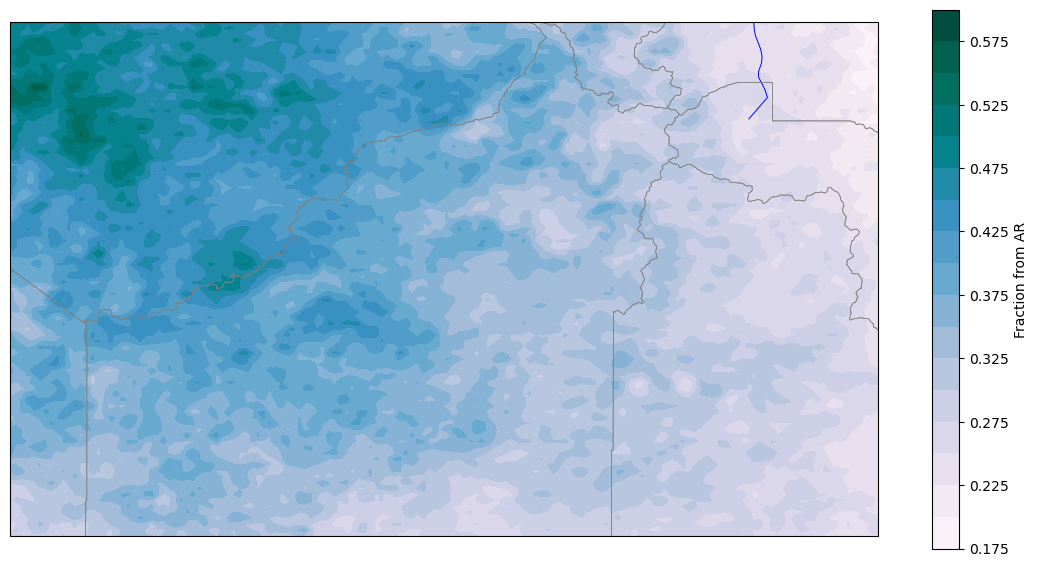

In [ ]:
fig, ax = plt.subplots(figsize=(14, 7), subplot_kw={'projection': projection})

states = cfeature.NaturalEarthFeature(
    category='cultural',
    name='admin_1_states_provinces_lines',
    scale='10m',
    facecolor='none'
)

rivers = cfeature.NaturalEarthFeature(
    category='physical',
    name='rivers_lake_centerlines',
    scale='10m',
    facecolor='none'
)

im = ax.contourf(ar_frac['lon'], ar_frac['lat'], ar_frac, levels=15, cmap='PuBuGn',transform=projection)

# Add features
ax.add_feature(states, edgecolor='black', linewidth=0.7)
ax.add_feature(rivers, edgecolor='blue', linewidth=0.7)
ax.add_feature(USCOUNTIES.with_scale('500k'), edgecolor='gray', linewidth=0.5)

# -----------------------------
# Lat/lon gridlines + labels
# -----------------------------

gl = ax.gridlines(
    crs=ccrs.PlateCarree(),
    linewidth=0.5,
    linestyle='--',
)

# Force labels only on bottom & left
# gl.top_labels = False
# gl.right_labels = False
gl.bottom_labels = True
gl.left_labels = True

# Formatting
gl.xformatter = LongitudeFormatter()
gl.yformatter = LatitudeFormatter()

plt.colorbar(im, ax=ax, orientation='vertical', label='Fraction from AR')
plt.show()

In [12]:
ar_frac

<xarray.DataArray 'Rainf' (lat: 88, lon: 148)> Size: 52kB
dask.array<truediv, shape=(88, 148), dtype=float32, chunksize=(88, 148), chunktype=numpy.ndarray>
Coordinates:
  * lon      (lon) float32 592B -116.1 -116.1 -116.1 ... -114.7 -114.6 -114.6
  * lat      (lat) float32 352B 43.22 43.24 43.24 43.26 ... 44.08 44.08 44.1